<a href="https://colab.research.google.com/github/sumera21/Deeplearning/blob/main/SliceFormer_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SliceFormer

**Project:** Vulnerability Detection in C Source Code via Program-Slice-Augmented Transformers

**Author:** Sumera Anjum

CSCE 5218 Deep Learning

**Dataset:** Devign / CodeXGLUE Defect Detection

## How to run

1. Upload this notebook.
2. `Runtime → Change runtime type → T4 GPU`.
3. `Runtime → Run all`.

**Two run modes:** the `CONFIG` cell has a `QUICK_MODE` switch. Default is `False` (full reproduction run, ~3–4 hours on T4). Flip to `True` for a 20-minute pipeline check.


## 1. Install dependencies

In [ ]:
%pip install -q torch transformers==4.44.2 datasets==2.21.0 \
     scikit-learn matplotlib seaborn tqdm pandas gdown
%pip install -q tree-sitter==0.21.3 tree-sitter-languages==1.10.2



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 48.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 502.2/502.2 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 69.1 MB/s eta 0:00:00


## 2. Imports and configuration

mount Google Drive so checkpoints survive runtime disconnects.

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

import os
import re
import json
import random
import logging
import warnings
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional, Set

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve,
)

from transformers import (
    AutoTokenizer, AutoModel,
    get_linear_schedule_with_warmup,
    logging as hf_logging,
)

warnings.filterwarnings("ignore")
hf_logging.set_verbosity_error()
logging.basicConfig(format="%(asctime)s  %(levelname)s  %(message)s",
                    datefmt="%H:%M:%S", level=logging.INFO)
logger = logging.getLogger("sliceformer")

CONFIG = {
    # --- model names ---
    "full_model_name":  "microsoft/graphcodebert-base",
    "slice_model_name": "microsoft/codebert-base",

    # --- tokenization ---
    "block_size":      400,
    "slice_len":       128,
    "max_slices":      5,

    # --- SliceFormer architecture ---
    "num_attn_heads":        8,
    "dropout":               0.1,
    "freeze_slice_layers":   8,
    "freeze_full_layers":    0,

    # --- training ---
    "lr":               2e-5,
    "lr_new_mult":      10.0,
    "weight_decay":     0.01,
    "warmup_ratio":     0.1,
    "max_grad_norm":    1.0,
    "use_class_weights": True,
    "tune_threshold":    True,
    "seed":             42,
    "fp16":             True,

    # --- run mode ---
    "QUICK_MODE":        False,
    "quick_train_size":  1500,
    "quick_val_size":    300,
    "quick_test_size":   500,
    "quick_epochs":      1,
    "quick_batch_base":  8,
    "quick_batch_slf":   4,
    "full_epochs":       3,
    "full_batch_base":   16,
    "full_batch_slf":    8,
}

random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG["seed"])

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU:    {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected — training will be very slow.")

NUM_EPOCHS = CONFIG["quick_epochs"] if CONFIG["QUICK_MODE"] else CONFIG["full_epochs"]
BATCH_BASE = CONFIG["quick_batch_base"] if CONFIG["QUICK_MODE"] else CONFIG["full_batch_base"]
BATCH_SLF  = CONFIG["quick_batch_slf"]  if CONFIG["QUICK_MODE"] else CONFIG["full_batch_slf"]
print(f"Mode:   {'QUICK' if CONFIG['QUICK_MODE'] else 'FULL'}  |  epochs={NUM_EPOCHS}  |  batch={BATCH_BASE}/{BATCH_SLF}")
print(f"Improvements active:")
print(f"  * guard-aware slicing      = ENABLED")
print(f"  * class-weighted loss      = {CONFIG['use_class_weights']}")
print(f"  * freeze_slice_layers      = {CONFIG['freeze_slice_layers']} (of 12)")
print(f"  * validation threshold tune= {CONFIG['tune_threshold']}")


Mounted at /content/drive
Device: cuda
GPU:    Tesla T4
Memory: 15.6 GB
Mode:   FULL  |  epochs=3  |  batch=16/8
Improvements active:
  * guard-aware slicing      = ENABLED
  * class-weighted loss      = True
  * freeze_slice_layers      = 8 (of 12)
  * validation threshold tune= True


## 3. Program slicer - **guard-aware**

Two-tier slicer with **guard-aware extension**:

1. **Tree-sitter slicer** (preferred). Parses C into an AST, finds risky nodes, and now **walks up the AST from each risky node to pull in the conditions of enclosing `if`/`for`/`while`/`switch`/`do`** statements. This is what fixes the SAFE-vs-VULN distinction in the proposal: the slice for the SAFE function will explicitly contain `if (user_len > size) return -1;`.
2. **Regex fallback** (Python 3.12 / no tree-sitter). Adds a heuristic: when expanding the ±4-line window around a risky line, also pull in any `if (`/`while (`/`for (` lines anywhere in the function whose conditions reference variables used in the risky line.

Each function yields up to `max_slices` (=5) `Slice` objects.

In [ ]:
# ── tree-sitter setup ──────────────────────────────────────
try:
    from tree_sitter_languages import get_language, get_parser
    C_LANGUAGE = get_language("c")
    C_PARSER   = get_parser("c")
    TREE_SITTER_AVAILABLE = True
    print("[slicer] tree-sitter-languages available — using AST-based slicer.")
except Exception as _e:
    TREE_SITTER_AVAILABLE = False
    print(f"[slicer] tree-sitter unavailable ({type(_e).__name__}): falling back to regex slicer.")


MEMORY_FUNCS = {
    "malloc", "calloc", "realloc", "free", "alloca",
    "memcpy", "memmove", "memset", "strcpy", "strncpy",
    "strcat", "strncat", "sprintf", "snprintf", "gets", "scanf",
}

RISKY_PATTERNS = [
    r"\bmalloc\s*\(",   r"\bcalloc\s*\(",   r"\brealloc\s*\(",
    r"\bfree\s*\(",     r"\bmemcpy\s*\(",   r"\bstrcpy\s*\(",
    r"\bstrncpy\s*\(",  r"\bstrcat\s*\(",   r"\bsprintf\s*\(",
    r"\bgets\s*\(",
    r"\[\s*\w+\s*\]",         # array subscript
    r"\*\s*\w+\s*=",           # pointer write
    r"->",                         # struct pointer access
    r"\bNULL\b",
    r"\bsizeof\s*\(",
]
COMBINED_PATTERN = re.compile("|".join(RISKY_PATTERNS))

# guards = control-flow nodes whose CONDITION lines we always pull in
GUARD_NODE_TYPES = {
    "if_statement", "for_statement", "while_statement",
    "do_statement", "switch_statement",
}


@dataclass
class Slice:
    lines: List[str]
    line_indices: List[int]
    slice_type: str
    trigger_line: int

    def to_text(self) -> str:
        return "\n".join(self.lines)

    def __len__(self):
        return len(self.lines)


# ── Tree-sitter slicer with guard-awareness ────────────────────────────
class TreeSitterSlicer:
    RISKY_NODE_TYPES = {
        "call_expression", "subscript_expression", "pointer_declarator",
        "pointer_expression", "assignment_expression", "binary_expression",
    }

    def __init__(self):
        self.parser   = C_PARSER
        self.language = C_LANGUAGE

    def _is_memory_call(self, node, source_bytes):
        if node.type != "call_expression":
            return False
        f = node.child_by_field_name("function")
        if f is None:
            return False
        name = source_bytes[f.start_byte:f.end_byte].decode("utf-8", errors="ignore")
        return name in MEMORY_FUNCS

    def _collect_risky(self, root, source_bytes):
        out, q = [], [root]
        while q:
            n = q.pop(0)
            if n.type in self.RISKY_NODE_TYPES:
                if n.type == "call_expression":
                    if self._is_memory_call(n, source_bytes):
                        out.append(n)
                else:
                    out.append(n)
            q.extend(n.children)
        return out

    def _variables(self, node, source_bytes):
        names, q = set(), [node]
        while q:
            n = q.pop(0)
            if n.type == "identifier":
                names.add(source_bytes[n.start_byte:n.end_byte].decode("utf-8", errors="ignore"))
            q.extend(n.children)
        return names

    def _enclosing_guards(self, node) -> List[Tuple[int, int]]:
        """
        Walk up the AST from `node`. For every enclosing if/while/for/switch,
        return (start_line, end_line) of its CONDITION line(s) — not the body.
        This is the guard-aware extension.
        """
        guards = []
        cur = node.parent
        while cur is not None:
            if cur.type in GUARD_NODE_TYPES:
                # for an if/while/switch, the condition is in field 'condition'
                # for a for_statement, fields are 'initializer', 'condition', 'update'
                cond = cur.child_by_field_name("condition")
                if cond is not None:
                    guards.append((cond.start_point[0], cond.end_point[0]))
                else:
                    # fallback: take the first line of the construct (header line)
                    guards.append((cur.start_point[0], cur.start_point[0]))
            cur = cur.parent
        return guards

    def _backward_slice(self, trigger, variables, lines, context=3):
        keep = {trigger}
        for i in range(max(0, trigger - 1), -1, -1):
            if any(re.search(r"\b" + re.escape(v) + r"\b", lines[i]) for v in variables):
                keep.add(i)
            if i < trigger - 15:
                break
        for i in range(max(0, trigger - context), min(len(lines), trigger + context + 1)):
            keep.add(i)
        return keep

    def extract(self, code: str, max_slices: int = 5) -> List[Slice]:
        if not code.strip():
            return []
        source_bytes = code.encode("utf-8")
        lines = code.splitlines()
        try:
            tree = self.parser.parse(source_bytes)
        except Exception:
            return _regex_fallback(code, max_slices)

        risky = self._collect_risky(tree.root_node, source_bytes)
        if not risky:
            return _regex_fallback(code, max_slices)

        slices, seen = [], set()
        for node in risky:
            trig = node.start_point[0]
            if trig in seen:
                continue
            seen.add(trig)
            vars_ = self._variables(node, source_bytes)
            keep = self._backward_slice(trig, vars_, lines)

            # GUARD-AWARE: include every enclosing if/while/for condition line
            for (g_start, g_end) in self._enclosing_guards(node):
                for i in range(g_start, g_end + 1):
                    if 0 <= i < len(lines):
                        keep.add(i)

            idx = sorted(keep)
            stype = (
                "memory_op"    if node.type == "call_expression" else
                "array_access" if node.type == "subscript_expression" else
                "pointer_decl" if node.type == "pointer_declarator" else
                "arithmetic"
            )
            slices.append(Slice(
                lines=[lines[i] for i in idx if i < len(lines)],
                line_indices=idx, slice_type=stype, trigger_line=trig,
            ))
            if len(slices) >= max_slices:
                break
        return slices if slices else _regex_fallback(code, max_slices)


def _regex_fallback(code: str, max_slices: int = 5) -> List[Slice]:
    """Regex slicer with guard-awareness heuristic."""
    lines  = code.splitlines()
    slices = []
    seen   = set()
    WINDOW = 4

    # Pre-find all guard lines (if/while/for/switch headers) in the function
    guard_re = re.compile(r"^\s*(if|while|for|switch)\s*\(")
    guard_lines = [(i, line) for i, line in enumerate(lines) if guard_re.search(line)]

    def _vars_in(line):
        return set(re.findall(r"\b[A-Za-z_]\w*\b", line))

    for i, line in enumerate(lines):
        if COMBINED_PATTERN.search(line) and i not in seen:
            s = max(0, i - WINDOW)
            e = min(len(lines), i + WINDOW + 1)
            idx = set(range(s, e))
            seen.update(idx)

            # GUARD-AWARE: include any guard line that mentions a var the risky line uses
            risky_vars = _vars_in(line)
            for gi, gline in guard_lines:
                if _vars_in(gline) & risky_vars:
                    idx.add(gi)

            idx = sorted(idx)

            if re.search(r"\b(malloc|calloc|realloc|free|memcpy|strcpy)\s*\(", line):
                stype = "memory_op"
            elif re.search(r"\[\s*\w+\s*\]", line):
                stype = "array_access"
            elif re.search(r"\bNULL\b", line):
                stype = "null_check"
            else:
                stype = "pointer_op"
            slices.append(Slice([lines[j] for j in idx], idx, stype, i))
            if len(slices) >= max_slices:
                break
    return slices


_slicer_instance = None
def get_slicer():
    global _slicer_instance
    if _slicer_instance is None and TREE_SITTER_AVAILABLE:
        _slicer_instance = TreeSitterSlicer()
    return _slicer_instance


def extract_slices(code: str, max_slices: int = 5) -> List[Slice]:
    s = get_slicer()
    return s.extract(code, max_slices) if s is not None else _regex_fallback(code, max_slices)


def slices_to_text(slices, separator=" [SEP] "):
    return separator.join(s.to_text() for s in slices) if slices else ""


[slicer] tree-sitter-languages available — using AST-based slicer.


In [ ]:
# Verify guard-aware slicing on the proposal's two examples
VULN = '''int decode_frame(...) {
    uint8_t *buf = malloc(size);
    memcpy(buf, src, user_len);
    free(buf);
}'''
SAFE = '''int decode_frame(...) {
    uint8_t *buf = malloc(size);
    if (user_len > size) return -1;
    memcpy(buf, src, user_len);
    free(buf);
}'''
for name, src in [("VULN", VULN), ("SAFE", SAFE)]:
    sl = extract_slices(src, max_slices=5)
    print(f"── {name} — {len(sl)} slice(s) extracted ──")
    for i, s in enumerate(sl):
        guards_in_slice = sum(1 for ln in s.lines if re.search(r"\b(if|while|for|switch)\s*\(", ln))
        print(f"  [{i}] type={s.slice_type}, trigger_line={s.trigger_line}, "
              f"lines={len(s)}, guards_present={guards_in_slice}")
        # Print the actual slice text — confirms the guard is captured for SAFE
        for ln in s.lines:
            print(f"        | {ln}")
    print()


── VULN — 3 slice(s) extracted ──
  [0] type=memory_op, trigger_line=2, lines=5, guards_present=0
        | int decode_frame(...) {
        |     uint8_t *buf = malloc(size);
        |     memcpy(buf, src, user_len);
        |     free(buf);
        | }
  [1] type=memory_op, trigger_line=3, lines=5, guards_present=0
        | int decode_frame(...) {
        |     uint8_t *buf = malloc(size);
        |     memcpy(buf, src, user_len);
        |     free(buf);
        | }
  [2] type=pointer_decl, trigger_line=1, lines=5, guards_present=0
        | int decode_frame(...) {
        |     uint8_t *buf = malloc(size);
        |     memcpy(buf, src, user_len);
        |     free(buf);
        | }

── SAFE — 4 slice(s) extracted ──
  [0] type=memory_op, trigger_line=3, lines=6, guards_present=1
        | int decode_frame(...) {
        |     uint8_t *buf = malloc(size);
        |     if (user_len > size) return -1;
        |     memcpy(buf, src, user_len);
        |     free(buf);
        | }
  

## 4. Load the Devign dataset

In [ ]:
from datasets import load_dataset

try:
    ds = load_dataset("google/code_x_glue_cc_defect_detection")
    print("Loaded from Hugging Face Hub.")
except Exception as e:
    print(f"Hub load failed: {e}\nFalling back to direct JSONL download...")
    import urllib.request
    from datasets import Dataset, DatasetDict
    BASE = "https://huggingface.co/datasets/google/code_x_glue_cc_defect_detection/resolve/main"
    tmp = {}
    for split, fname in [("train", "train.jsonl"),
                         ("validation", "valid.jsonl"),
                         ("test", "test.jsonl")]:
        url = f"{BASE}/{fname}"
        print(f"  downloading {url}")
        with urllib.request.urlopen(url) as r:
            records = [json.loads(line) for line in r.read().decode().splitlines() if line.strip()]
        tmp[split] = Dataset.from_list(records)
    ds = DatasetDict(tmp)

print(ds)


Generating train split:   0%|          | 0/21854 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2732 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2732 [00:00<?, ? examples/s]

Loaded from Hugging Face Hub.
DatasetDict({
    train: Dataset({
        features: ['id', 'func', 'target', 'project', 'commit_id'],
        num_rows: 21854
    })
    validation: Dataset({
        features: ['id', 'func', 'target', 'project', 'commit_id'],
        num_rows: 2732
    })
    test: Dataset({
        features: ['id', 'func', 'target', 'project', 'commit_id'],
        num_rows: 2732
    })
})


In [ ]:
def to_list(split):
    return [{"func": f, "target": t, "idx": i}
            for i, (f, t) in enumerate(zip(split["func"], split["target"]))]

train_data = to_list(ds["train"])
val_data   = to_list(ds["validation"])
test_data  = to_list(ds["test"])

random.Random(CONFIG["seed"]).shuffle(train_data)
random.Random(CONFIG["seed"]).shuffle(val_data)

if CONFIG["QUICK_MODE"]:
    train_data = train_data[:CONFIG["quick_train_size"]]
    val_data   = val_data[:CONFIG["quick_val_size"]]
    test_data  = test_data[:CONFIG["quick_test_size"]]

# Compute class weights for use in the loss
n_pos = sum(d["target"] for d in train_data)
n_neg = len(train_data) - n_pos
pos_weight = n_neg / max(n_pos, 1)
CLASS_WEIGHTS = torch.tensor([1.0, pos_weight], dtype=torch.float, device=DEVICE)

print(f"train={len(train_data)}  val={len(val_data)}  test={len(test_data)}")
for name, d in [("train", train_data), ("val", val_data), ("test", test_data)]:
    pos = sum(x["target"] for x in d)
    print(f"  {name}: {pos} vulnerable ({100*pos/len(d):.1f}%)")
print(f"\nClass weights for loss: secure={CLASS_WEIGHTS[0]:.3f}  vulnerable={CLASS_WEIGHTS[1]:.3f}")


train=21854  val=2732  test=2732
  train: 10018 vulnerable (45.8%)
  val: 1187 vulnerable (43.4%)
  test: 1255 vulnerable (45.9%)

Class weights for loss: secure=1.000  vulnerable=1.181


## 5. `DevignDataset`

In [ ]:
class DevignDataset(Dataset):
    def __init__(self, data, full_tok, slice_tok,
                 block_size=400, slice_len=128, max_slices=5, cache_slices=True):
        self.data         = data
        self.full_tok     = full_tok
        self.slice_tok    = slice_tok
        self.block_size   = block_size
        self.slice_len    = slice_len
        self.max_slices   = max_slices
        self.cache_slices = cache_slices
        self._cache: Dict[int, List[Slice]] = {}

    def __len__(self):
        return len(self.data)

    def _get_slices(self, idx, code):
        if self.cache_slices and idx in self._cache:
            return self._cache[idx]
        sl = extract_slices(code, max_slices=self.max_slices)
        if self.cache_slices:
            self._cache[idx] = sl
        return sl

    def _tok_full(self, code):
        enc = self.full_tok(code, max_length=self.block_size,
                            padding="max_length", truncation=True, return_tensors="pt")
        return enc["input_ids"].squeeze(0), enc["attention_mask"].squeeze(0)

    def _tok_slices(self, slices):
        ids_rows, mask_rows, real = [], [], []
        for i in range(self.max_slices):
            if i < len(slices):
                enc = self.slice_tok(slices[i].to_text(), max_length=self.slice_len,
                                     padding="max_length", truncation=True, return_tensors="pt")
                ids_rows.append(enc["input_ids"].squeeze(0))
                mask_rows.append(enc["attention_mask"].squeeze(0))
                real.append(1)
            else:
                ids_rows.append(torch.zeros(self.slice_len, dtype=torch.long))
                mask_rows.append(torch.zeros(self.slice_len, dtype=torch.long))
                real.append(0)
        return (torch.stack(ids_rows),
                torch.stack(mask_rows),
                torch.tensor(real, dtype=torch.float))

    def __getitem__(self, idx):
        item = self.data[idx]
        code  = item["func"]
        label = int(item["target"])
        full_ids, full_mask = self._tok_full(code)
        slices = self._get_slices(idx, code)
        slice_ids, slice_attn, slice_mask = self._tok_slices(slices)
        return {
            "full_input_ids":       full_ids,
            "full_attention_mask":  full_mask,
            "slice_input_ids":      slice_ids,
            "slice_attention_mask": slice_attn,
            "slice_mask":           slice_mask,
            "labels":               torch.tensor(label, dtype=torch.long),
            "idx":                  torch.tensor(item.get("idx", idx), dtype=torch.long),
        }


In [ ]:
print("Loading tokenizers...")
full_tok  = AutoTokenizer.from_pretrained(CONFIG["full_model_name"])
slice_tok = AutoTokenizer.from_pretrained(CONFIG["slice_model_name"])

ds_kw = dict(
    full_tok=full_tok, slice_tok=slice_tok,
    block_size=CONFIG["block_size"], slice_len=CONFIG["slice_len"],
    max_slices=CONFIG["max_slices"], cache_slices=True,
)
train_ds = DevignDataset(train_data, **ds_kw)
val_ds   = DevignDataset(val_data,   **ds_kw)
test_ds  = DevignDataset(test_data,  **ds_kw)

sample = train_ds[0]
for k, v in sample.items():
    if torch.is_tensor(v):
        print(f"  {k:<22} shape={tuple(v.shape)}  dtype={v.dtype}")


Loading tokenizers...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/539 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

  full_input_ids         shape=(400,)  dtype=torch.int64
  full_attention_mask    shape=(400,)  dtype=torch.int64
  slice_input_ids        shape=(5, 128)  dtype=torch.int64
  slice_attention_mask   shape=(5, 128)  dtype=torch.int64
  slice_mask             shape=(5,)  dtype=torch.float32
  labels                 shape=()  dtype=torch.int64
  idx                    shape=()  dtype=torch.int64


In [ ]:
print("=" * 70)
print("BASELINES")
print("=" * 70)

# ─────────────────────────────────────────────────────────────────────────
# Baseline 1: Random Baseline (uniform random 0 or 1)
# ─────────────────────────────────────────────────────────────────────────
print("\n[BASELINE 1] Random Baseline")
random.seed(CONFIG["seed"])
test_labels = np.array([d["target"] for d in test_data])
test_preds_random = np.random.randint(0, 2, size=len(test_data))
test_probs_random = np.random.uniform(0, 1, size=len(test_data))

random_metrics = {
    "accuracy": accuracy_score(test_labels, test_preds_random),
    "precision": precision_score(test_labels, test_preds_random, zero_division=0),
    "recall": recall_score(test_labels, test_preds_random, zero_division=0),
    "f1": f1_score(test_labels, test_preds_random, zero_division=0),
    "auc": roc_auc_score(test_labels, test_probs_random),
    "preds": test_preds_random,
    "labels": test_labels,
    "probs": test_probs_random,
    "threshold": 0.5,
}

for k in ["accuracy", "precision", "recall", "f1", "auc"]:
    print(f" {k:<10} = {random_metrics[k]:.4f}")

# ─────────────────────────────────────────────────────────────────────────
# Baseline 2: Most-Frequent Baseline (always predict majority class 0)
# ─────────────────────────────────────────────────────────────────────────
print("\n[BASELINE 2] Most-Frequent Baseline (majority class)")
test_preds_majority = np.zeros(len(test_data), dtype=np.int64)
test_probs_majority = np.zeros(len(test_data))  # prob of class 1

majority_metrics = {
    "accuracy": accuracy_score(test_labels, test_preds_majority),
    "precision": precision_score(test_labels, test_preds_majority, zero_division=0),
    "recall": recall_score(test_labels, test_preds_majority, zero_division=0),
    "f1": f1_score(test_labels, test_preds_majority, zero_division=0),
    "auc": roc_auc_score(test_labels, test_probs_majority),
    "preds": test_preds_majority,
    "labels": test_labels,
    "probs": test_probs_majority,
    "threshold": 0.5,
}

for k in ["accuracy", "precision", "recall", "f1", "auc"]:
    print(f" {k:<10} = {majority_metrics[k]:.4f}")

# ─────────────────────────────────────────────────────────────────────────
# Baseline 3: TF-IDF + Logistic Regression
# ─────────────────────────────────────────────────────────────────────────
print("\n[BASELINE 3] TF-IDF + Logistic Regression")
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Extract source code from train and test sets
train_codes = [d["func"] for d in train_data]
train_targets = np.array([d["target"] for d in train_data])
test_codes = [d["func"] for d in test_data]

# Fit TF-IDF on training data
print("  Fitting TF-IDF vectorizer...")
tfidf = TfidfVectorizer(
    max_features=5000,  # Limit to top 5000 features to avoid OOM
    ngram_range=(1, 2),  # Unigrams and bigrams
    min_df=2,
    max_df=0.8,
)
X_train_tfidf = tfidf.fit_transform(train_codes)
X_test_tfidf = tfidf.transform(test_codes)

# Fit Logistic Regression
print("  Training Logistic Regression...")
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=CONFIG["seed"],
    n_jobs=-1,
    class_weight='balanced',  # Account for class imbalance
)
lr_model.fit(X_train_tfidf, train_targets)

# Predict on test set
test_probs_tfidf = lr_model.predict_proba(X_test_tfidf)[:, 1]
test_preds_tfidf = lr_model.predict(X_test_tfidf)

tfidf_metrics = {
    "accuracy": accuracy_score(test_labels, test_preds_tfidf),
    "precision": precision_score(test_labels, test_preds_tfidf, zero_division=0),
    "recall": recall_score(test_labels, test_preds_tfidf, zero_division=0),
    "f1": f1_score(test_labels, test_preds_tfidf, zero_division=0),
    "auc": roc_auc_score(test_labels, test_probs_tfidf),
    "preds": test_preds_tfidf,
    "labels": test_labels,
    "probs": test_probs_tfidf,
    "threshold": 0.5,
}

for k in ["accuracy", "precision", "recall", "f1", "auc"]:
    print(f" {k:<10} = {tfidf_metrics[k]:.4f}")

# ─────────────────────────────────────────────────────────────────────────
# Store all baselines in a dictionary for comparison
# ─────────────────────────────────────────────────────────────────────────
BASELINES = {
    "Random": random_metrics,
    "Most-Frequent": majority_metrics,
    "TF-IDF + LogReg": tfidf_metrics,
}

print("\n" + "=" * 70)
print("BASELINES SUMMARY TABLE")
print("=" * 70)

metric_keys = ["accuracy", "precision", "recall", "f1", "auc"]
rows_baseline = []
for m in metric_keys:
    row = {"Metric": m.upper()}
    for name, res in BASELINES.items():
        row[name] = f"{res[m]:.4f}"
    rows_baseline.append(row)

baseline_df = pd.DataFrame(rows_baseline)
print(baseline_df.to_string(index=False))


BASELINES

[BASELINE 1] Random Baseline
 accuracy   = 0.5062
 precision  = 0.4652
 recall     = 0.5012
 f1         = 0.4825
 auc        = 0.4881

[BASELINE 2] Most-Frequent Baseline (majority class)
 accuracy   = 0.5406
 precision  = 0.0000
 recall     = 0.0000
 f1         = 0.0000
 auc        = 0.5000

[BASELINE 3] TF-IDF + Logistic Regression
  Fitting TF-IDF vectorizer...
  Training Logistic Regression...
 accuracy   = 0.5875
 precision  = 0.5451
 recall     = 0.6159
 f1         = 0.5784
 auc        = 0.6371

BASELINES SUMMARY TABLE
   Metric Random Most-Frequent TF-IDF + LogReg
 ACCURACY 0.5062        0.5406          0.5875
PRECISION 0.4652        0.0000          0.5451
   RECALL 0.5012        0.0000          0.6159
       F1 0.4825        0.0000          0.5784
      AUC 0.4881        0.5000          0.6371


## 6. Models

The three model classes. Forward signatures unchanged from the original. The training loop will compute a class-weighted loss externally rather than using the model's internal one — this lets us apply the loss reweighting uniformly across all three models without modifying each `forward()`.

### 6.1 `CodeBERTBaseline` (Experiment 1)

In [ ]:
class CodeBERTBaseline(nn.Module):
    def __init__(self, model_name="microsoft/codebert-base", dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        h = self.encoder.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(h, h), nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(h, 2),
        )

    def forward(self, full_input_ids, full_attention_mask, labels=None, **unused):
        out = self.encoder(input_ids=full_input_ids, attention_mask=full_attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        logits = self.classifier(cls)
        result = {"logits": logits}
        if labels is not None:
            result["loss"] = F.cross_entropy(logits, labels)
        return result

    def count_parameters(self):
        t = sum(p.numel() for p in self.parameters())
        train = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return {"total": t, "trainable": train}


### 6.2 `GraphCodeBERTBaseline` (Experiment 2)

In [ ]:
class GraphCodeBERTBaseline(nn.Module):
    def __init__(self, model_name="microsoft/graphcodebert-base", dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        h = self.encoder.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(h, h), nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(h, 2),
        )

    def forward(self, full_input_ids, full_attention_mask, labels=None, **unused):
        out = self.encoder(input_ids=full_input_ids, attention_mask=full_attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        logits = self.classifier(cls)
        result = {"logits": logits}
        if labels is not None:
            result["loss"] = F.cross_entropy(logits, labels)
        return result

    def count_parameters(self):
        t = sum(p.numel() for p in self.parameters())
        train = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return {"total": t, "trainable": train}


### 6.3 `SliceFormer`

`freeze_slice_layers=8` means embeddings + bottom 8 transformer layers frozen, **top 4 layers trainable**; the half of CodeBERT that adapts to slice-shaped input.

In [ ]:
class SliceFormer(nn.Module):
    def __init__(
        self,
        full_model_name     = "microsoft/graphcodebert-base",
        slice_model_name    = "microsoft/codebert-base",
        num_attn_heads      = 8,
        dropout             = 0.1,
        freeze_full_layers  = 0,
        freeze_slice_layers = 8,   # CHANGED default
    ):
        super().__init__()
        self.full_encoder  = AutoModel.from_pretrained(full_model_name)
        self.slice_encoder = AutoModel.from_pretrained(slice_model_name)

        h_full  = self.full_encoder.config.hidden_size
        h_slice = self.slice_encoder.config.hidden_size
        assert h_full == h_slice
        H = h_full

        self._freeze_bottom_layers(self.full_encoder,  freeze_full_layers)
        self._freeze_bottom_layers(self.slice_encoder, freeze_slice_layers)

        self.cross_attention = nn.MultiheadAttention(
            embed_dim=H, num_heads=num_attn_heads,
            dropout=dropout, batch_first=True,
        )
        self.post_attn_ln = nn.LayerNorm(H)

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(H * 2, H), nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(H, 2),
        )

    @staticmethod
    def _freeze_bottom_layers(encoder, k):
        if k <= 0:
            return
        for p in encoder.embeddings.parameters():
            p.requires_grad = False
        layers = encoder.encoder.layer
        for i in range(min(k, len(layers))):
            for p in layers[i].parameters():
                p.requires_grad = False

    def _encode_slices(self, slice_input_ids, slice_attention_mask):
        B, N, L = slice_input_ids.shape
        flat_ids  = slice_input_ids.view(B * N, L)
        flat_mask = slice_attention_mask.view(B * N, L)
        out = self.slice_encoder(input_ids=flat_ids, attention_mask=flat_mask)
        cls = out.last_hidden_state[:, 0, :]
        return cls.view(B, N, -1)

    def forward(
        self,
        full_input_ids,  full_attention_mask,
        slice_input_ids, slice_attention_mask, slice_mask,
        labels=None, **unused,
    ):
        full_out = self.full_encoder(
            input_ids=full_input_ids, attention_mask=full_attention_mask)
        cls_full = full_out.last_hidden_state[:, 0:1, :]

        slice_cls = self._encode_slices(slice_input_ids, slice_attention_mask)

        key_padding_mask = slice_mask == 0
        all_pad = key_padding_mask.all(dim=1)
        if all_pad.any():
            key_padding_mask = key_padding_mask.clone()
            key_padding_mask[all_pad, 0] = False

        attended, _ = self.cross_attention(
            query=cls_full, key=slice_cls, value=slice_cls,
            key_padding_mask=key_padding_mask,
        )
        attended = self.post_attn_ln(attended + cls_full)

        fused = torch.cat([cls_full.squeeze(1), attended.squeeze(1)], dim=-1)
        logits = self.classifier(fused)
        result = {"logits": logits}
        if labels is not None:
            result["loss"] = F.cross_entropy(logits, labels)
        return result

    def count_parameters(self):
        t = sum(p.numel() for p in self.parameters())
        train = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return {"total": t, "trainable": train, "frozen": t - train}


## 7. Training and evaluation utilities

Three things the new training loop does:

1. **Class-weighted loss.** Replaces the model's internal `cross_entropy(logits, labels)` with `cross_entropy(logits, labels, weight=CLASS_WEIGHTS)`. Applied uniformly to all three models.
2. **Best checkpoint by validation F1.** After each epoch, evaluates on val. If F1 improved, stashes a CPU copy of `state_dict`. After the last epoch, restores the best.
3. **Threshold tuning.** After training, scans 99 candidate thresholds on the validation set and picks the one that maximizes F1. The test-time evaluation uses *that* threshold instead of `argmax`.

In [ ]:
def build_optimizer(model, base_lr, new_lr_mult, weight_decay):
    no_decay = ["bias", "LayerNorm.weight"]
    enc, new = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        is_new = any(k in name for k in ["cross_attention", "classifier", "post_attn_ln"])
        group  = new if is_new else enc
        wd     = 0.0 if any(nd in name for nd in no_decay) else weight_decay
        group.append({"params": [p], "weight_decay": wd})
    for g in new:
        g["lr"] = base_lr * new_lr_mult
    return AdamW(enc + new, lr=base_lr)


@torch.no_grad()
def _collect_probs(model, loader, device):
    model.eval()
    all_labels, all_probs = [], []
    for batch in loader:
        labels = batch["labels"].to(device)
        kwargs = {k: v.to(device) for k, v in batch.items() if k not in ("labels", "idx")}
        logits = model(**kwargs)["logits"]
        probs  = torch.softmax(logits, dim=-1)[:, 1]
        all_labels.extend(labels.cpu().tolist())
        all_probs.extend(probs.cpu().tolist())
    return np.array(all_labels), np.array(all_probs)


def _metrics_at_threshold(labels, probs, threshold):
    preds = (probs >= threshold).astype(np.int64)
    try:
        auc = roc_auc_score(labels, probs)
    except ValueError:
        auc = float("nan")
    return {
        "accuracy":  accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall":    recall_score(labels, preds, zero_division=0),
        "f1":        f1_score(labels, preds, zero_division=0),
        "auc":       auc,
        "preds":     preds,
        "labels":    labels,
        "probs":     probs,
        "threshold": threshold,
    }


def tune_threshold_on_val(labels, probs):
    """Grid-search threshold in [0.05, 0.95] step 0.01, pick best by F1."""
    best_f1, best_t = -1.0, 0.5
    for t in np.linspace(0.05, 0.95, 91):
        preds = (probs >= t).astype(np.int64)
        f1 = f1_score(labels, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return float(best_t), float(best_f1)


def train_model(model, train_loader, val_loader, num_epochs, device, model_name,
                base_lr, new_lr_mult, weight_decay, warmup_ratio, max_grad_norm, fp16,
                class_weights=None):
    model.to(device)
    optimizer = build_optimizer(model, base_lr, new_lr_mult, weight_decay)
    total_steps  = len(train_loader) * num_epochs
    warmup_steps = int(warmup_ratio * total_steps)
    scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
    scaler = torch.amp.GradScaler("cuda") if (fp16 and device.type == "cuda") else None

    best_f1 = -1.0
    best_state = None
    history = []

    for epoch in range(1, num_epochs + 1):
        model.train()
        running, seen = 0.0, 0
        pbar = tqdm(train_loader, desc=f"[{model_name}] epoch {epoch}/{num_epochs}")
        for batch in pbar:
            labels = batch["labels"].to(device)
            kwargs = {k: v.to(device) for k, v in batch.items() if k not in ("labels", "idx")}

            optimizer.zero_grad()
            if scaler is not None:
                with torch.amp.autocast("cuda"):
                    out = model(**kwargs)
                    loss = F.cross_entropy(out["logits"], labels, weight=class_weights)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
                scaler.step(optimizer)
                scaler.update()
            else:
                out = model(**kwargs)
                loss = F.cross_entropy(out["logits"], labels, weight=class_weights)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
                optimizer.step()
            scheduler.step()

            bs = labels.size(0)
            running += loss.item() * bs
            seen    += bs
            pbar.set_postfix(loss=f"{running/seen:.4f}")

        # validate at default threshold for monitoring
        val_labels, val_probs = _collect_probs(model, val_loader, device)
        val_metrics = _metrics_at_threshold(val_labels, val_probs, 0.5)
        history.append({"epoch": epoch, "train_loss": running/seen,
                        "val_acc": val_metrics["accuracy"], "val_f1": val_metrics["f1"]})
        print(f"  → epoch {epoch}: train_loss={running/seen:.4f}  "
              f"val_acc={val_metrics['accuracy']:.4f}  val_f1={val_metrics['f1']:.4f}")

        # best-checkpoint tracking by F1
        if val_metrics["f1"] > best_f1:
            best_f1 = val_metrics["f1"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            print(f"    ★ new best val_f1={best_f1:.4f} (checkpoint cached)")

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"  Restored best checkpoint (val_f1={best_f1:.4f})")
    return history


def evaluate_with_threshold_tuning(model, val_loader, test_loader, device,
                                   tune_threshold=True, model_name="model"):
    """
    Pipeline: collect val probs -> pick best F1 threshold -> apply to test.
    If tune_threshold=False, uses 0.5 (== argmax for binary).
    """
    val_labels, val_probs = _collect_probs(model, val_loader, device)
    if tune_threshold:
        best_t, best_val_f1 = tune_threshold_on_val(val_labels, val_probs)
        print(f"  [{model_name}] tuned threshold = {best_t:.3f}  (val F1 at this t = {best_val_f1:.4f})")
    else:
        best_t = 0.5
        print(f"  [{model_name}] using default threshold = 0.5")

    test_labels, test_probs = _collect_probs(model, test_loader, device)
    test_metrics = _metrics_at_threshold(test_labels, test_probs, best_t)
    val_metrics  = _metrics_at_threshold(val_labels,  val_probs,  best_t)
    return test_metrics, val_metrics


def free_gpu():
    import gc
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


## 8. DataLoaders

In [ ]:
train_loader_base = DataLoader(train_ds, batch_size=BATCH_BASE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader_base   = DataLoader(val_ds,   batch_size=BATCH_BASE, shuffle=False, num_workers=2, pin_memory=True)
test_loader_base  = DataLoader(test_ds,  batch_size=BATCH_BASE, shuffle=False, num_workers=2, pin_memory=True)

train_loader_slf  = DataLoader(train_ds, batch_size=BATCH_SLF,  shuffle=True,  num_workers=2, pin_memory=True)
val_loader_slf    = DataLoader(val_ds,   batch_size=BATCH_SLF,  shuffle=False, num_workers=2, pin_memory=True)
test_loader_slf   = DataLoader(test_ds,  batch_size=BATCH_SLF,  shuffle=False, num_workers=2, pin_memory=True)

print(f"baseline batches    — train:{len(train_loader_base):>4} val:{len(val_loader_base):>3} test:{len(test_loader_base):>3}")
print(f"sliceformer batches — train:{len(train_loader_slf):>4} val:{len(val_loader_slf):>3} test:{len(test_loader_slf):>3}")


baseline batches    — train:1366 val:171 test:171
sliceformer batches — train:2732 val:342 test:342


## 9. Experiment 1 — CodeBERT baseline

In [ ]:
print("=" * 70)
print("EXPERIMENT 1:  CodeBERT baseline")
print("=" * 70)

codebert_model = CodeBERTBaseline(
    model_name=CONFIG["slice_model_name"],
    dropout=CONFIG["dropout"],
)
print(f"Parameters: {codebert_model.count_parameters()}")

cw = CLASS_WEIGHTS if CONFIG["use_class_weights"] else None
codebert_history = train_model(
    model=codebert_model,
    train_loader=train_loader_base, val_loader=val_loader_base,
    num_epochs=NUM_EPOCHS, device=DEVICE, model_name="CodeBERT",
    base_lr=CONFIG["lr"], new_lr_mult=CONFIG["lr_new_mult"],
    weight_decay=CONFIG["weight_decay"], warmup_ratio=CONFIG["warmup_ratio"],
    max_grad_norm=CONFIG["max_grad_norm"], fp16=CONFIG["fp16"],
    class_weights=cw,
)

print("\nEvaluating on TEST set...")
codebert_metrics, codebert_val_at_t = evaluate_with_threshold_tuning(
    codebert_model, val_loader_base, test_loader_base, DEVICE,
    tune_threshold=CONFIG["tune_threshold"], model_name="CodeBERT",
)
for k in ["accuracy", "precision", "recall", "f1", "auc", "threshold"]:
    print(f"  {k:<10} = {codebert_metrics[k]:.4f}")

del codebert_model
free_gpu()


EXPERIMENT 1:  CodeBERT baseline


pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Parameters: {'total': 125237762, 'trainable': 125237762}


[CodeBERT] epoch 1/3:   0%|          | 0/1366 [00:00<?, ?it/s]

  → epoch 1: train_loss=0.6617  val_acc=0.6321  val_f1=0.3831
    ★ new best val_f1=0.3831 (checkpoint cached)


...

  → epoch 3: train_loss=0.5503  val_acc=0.6376  val_f1=0.5929
    ★ new best val_f1=0.5929 (checkpoint cached)
  Restored best checkpoint (val_f1=0.5929)

Evaluating on TEST set...


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b27ae574400>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b27ae574400>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  [CodeBERT] tuned threshold = 0.300  (val F1 at this t = 0.6581)


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b27ae574400>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b27ae574400>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  accuracy   = 0.5926
  precision  = 0.5352
  recall     = 0.8598
  f1         = 0.6597
  auc        = 0.7045
  threshold  = 0.3000


## 10. Experiment 2 — GraphCodeBERT baseline

In [ ]:
print("=" * 70)
print("EXPERIMENT 2:  GraphCodeBERT baseline")
print("=" * 70)

graphcb_model = GraphCodeBERTBaseline(
    model_name=CONFIG["full_model_name"],
    dropout=CONFIG["dropout"],
)
print(f"Parameters: {graphcb_model.count_parameters()}")

graphcb_history = train_model(
    model=graphcb_model,
    train_loader=train_loader_base, val_loader=val_loader_base,
    num_epochs=NUM_EPOCHS, device=DEVICE, model_name="GraphCodeBERT",
    base_lr=CONFIG["lr"], new_lr_mult=CONFIG["lr_new_mult"],
    weight_decay=CONFIG["weight_decay"], warmup_ratio=CONFIG["warmup_ratio"],
    max_grad_norm=CONFIG["max_grad_norm"], fp16=CONFIG["fp16"],
    class_weights=cw,
)

print("\nEvaluating on TEST set...")
graphcb_metrics, graphcb_val_at_t = evaluate_with_threshold_tuning(
    graphcb_model, val_loader_base, test_loader_base, DEVICE,
    tune_threshold=CONFIG["tune_threshold"], model_name="GraphCodeBERT",
)
for k in ["accuracy", "precision", "recall", "f1", "auc", "threshold"]:
    print(f"  {k:<10} = {graphcb_metrics[k]:.4f}")

del graphcb_model
free_gpu()


EXPERIMENT 2:  GraphCodeBERT baseline


pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Parameters: {'total': 125237762, 'trainable': 125237762}


[GraphCodeBERT] epoch 1/3:   0%|          | 0/1366 [00:00<?, ?it/s]

  → epoch 1: train_loss=0.6838  val_acc=0.6164  val_f1=0.3466
    ★ new best val_f1=0.3466 (checkpoint cached)


...

[GraphCodeBERT] epoch 3/3:   0%|          | 0/1366 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b27ae574400>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b27ae574400>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  → epoch 3: train_loss=0.5330  val_acc=0.6504  val_f1=0.5846
  Restored best checkpoint (val_f1=0.6083)

Evaluating on TEST set...
  [GraphCodeBERT] tuned threshold = 0.330  (val F1 at this t = 0.6506)


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b27ae574400>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b27ae574400>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  accuracy   = 0.5805
  precision  = 0.5247
  recall     = 0.9235
  f1         = 0.6692
  auc        = 0.7157
  threshold  = 0.3300


## 11. Experiment — SliceFormer (proposed)

In [ ]:
print("=" * 70)
print("EXPERIMENT 4:  SliceFormer")
print("=" * 70)

sliceformer_model = SliceFormer(
    full_model_name     = CONFIG["full_model_name"],
    slice_model_name    = CONFIG["slice_model_name"],
    num_attn_heads      = CONFIG["num_attn_heads"],
    dropout             = CONFIG["dropout"],
    freeze_full_layers  = CONFIG["freeze_full_layers"],
    freeze_slice_layers = CONFIG["freeze_slice_layers"],
)
print(f"Parameters: {sliceformer_model.count_parameters()}")

sliceformer_history = train_model(
    model=sliceformer_model,
    train_loader=train_loader_slf, val_loader=val_loader_slf,
    num_epochs=NUM_EPOCHS, device=DEVICE, model_name="SliceFormer",
    base_lr=CONFIG["lr"], new_lr_mult=CONFIG["lr_new_mult"],
    weight_decay=CONFIG["weight_decay"], warmup_ratio=CONFIG["warmup_ratio"],
    max_grad_norm=CONFIG["max_grad_norm"], fp16=CONFIG["fp16"],
    class_weights=cw,
)

print("\nEvaluating on TEST set...")
sliceformer_metrics, sliceformer_val_at_t = evaluate_with_threshold_tuning(
    sliceformer_model, val_loader_slf, test_loader_slf, DEVICE,
    tune_threshold=CONFIG["tune_threshold"], model_name="SliceFormer",
)
for k in ["accuracy", "precision", "recall", "f1", "auc", "threshold"]:
    print(f"  {k:<10} = {sliceformer_metrics[k]:.4f}")


EXPERIMENT 4:  SliceFormer
Parameters: {'total': 252837122, 'trainable': 157133570, 'frozen': 95703552}


[SliceFormer] epoch 1/3:   0%|          | 0/2732 [00:00<?, ?it/s]

  → epoch 1: train_loss=0.7074  val_acc=0.6109  val_f1=0.3522
    ★ new best val_f1=0.3522 (checkpoint cached)


[SliceFormer] epoch 2/3:   0%|          | 0/2732 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b27ae574400>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b27ae574400>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

...

  → epoch 3: train_loss=0.5257  val_acc=0.6490  val_f1=0.6049
  Restored best checkpoint (val_f1=0.6255)

Evaluating on TEST set...


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b27ae574400>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b27ae574400>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  [SliceFormer] tuned threshold = 0.350  (val F1 at this t = 0.6529)


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b27ae574400>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b27ae574400>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  accuracy   = 0.6065
  precision  = 0.5449
  recall     = 0.8709
  f1         = 0.6703
  auc        = 0.7189
  threshold  = 0.3500


## 12. Compare all three models

In [ ]:
ALL_RESULTS = {
    "CodeBERT":      codebert_metrics,
    "GraphCodeBERT": graphcb_metrics,
    "SliceFormer":   sliceformer_metrics,
}

metric_keys = ["accuracy", "precision", "recall", "f1", "auc", "threshold"]
rows = []
for m in metric_keys:
    row = {"Metric": m.upper()}
    for name, res in ALL_RESULTS.items():
        row[name] = f"{res[m]:.4f}"
    base = ALL_RESULTS["CodeBERT"][m]
    row["Δ GCB"] = f"{ALL_RESULTS['GraphCodeBERT'][m] - base:+.4f}"
    row["Δ SF"]  = f"{ALL_RESULTS['SliceFormer'][m]   - base:+.4f}"
    rows.append(row)

results_df = pd.DataFrame(rows)
print("=" * 70)
print("TEST-SET COMPARISON — same test split for all three models")
print("=" * 70)
print(results_df.to_string(index=False))


TEST-SET COMPARISON — same test split for all three models
   Metric CodeBERT GraphCodeBERT SliceFormer   Δ GCB    Δ SF
 ACCURACY   0.5926        0.5805      0.6065 -0.0121 +0.0139
PRECISION   0.5352        0.5247      0.5449 -0.0105 +0.0096
   RECALL   0.8598        0.9235      0.8709 +0.0637 +0.0112
       F1   0.6597        0.6692      0.6703 +0.0094 +0.0106
      AUC   0.7045        0.7157      0.7189 +0.0111 +0.0144
THRESHOLD   0.3000        0.3300      0.3500 +0.0300 +0.0500


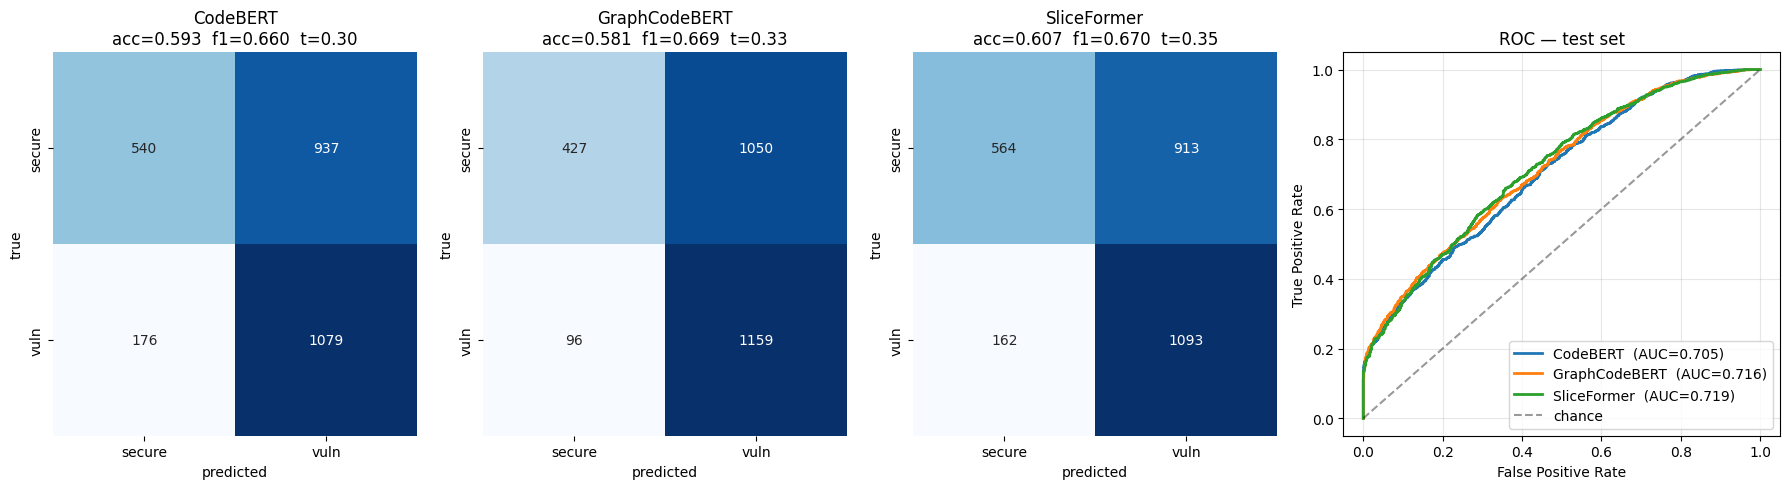

Saved: sliceformer_comparison.png


In [ ]:
fig = plt.figure(figsize=(18, 5))
gs  = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 1.2])

def _plot_cm(ax, metrics, title):
    cm = confusion_matrix(metrics["labels"], metrics["preds"], labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["secure", "vuln"], yticklabels=["secure", "vuln"], ax=ax)
    ax.set_title(title)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")

colors = {"CodeBERT": "tab:blue", "GraphCodeBERT": "tab:orange", "SliceFormer": "tab:green"}
for i, (name, res) in enumerate(ALL_RESULTS.items()):
    ax = fig.add_subplot(gs[0, i])
    _plot_cm(ax, res, f"{name}\nacc={res['accuracy']:.3f}  f1={res['f1']:.3f}  t={res['threshold']:.2f}")

ax_roc = fig.add_subplot(gs[0, 3])
for name, res in ALL_RESULTS.items():
    if not np.isnan(res["auc"]):
        fpr, tpr, _ = roc_curve(res["labels"], res["probs"])
        ax_roc.plot(fpr, tpr, color=colors[name], lw=2,
                    label=f"{name}  (AUC={res['auc']:.3f})")
ax_roc.plot([0, 1], [0, 1], "k--", alpha=0.4, label="chance")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("ROC — test set")
ax_roc.legend(loc="lower right")
ax_roc.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("sliceformer_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: sliceformer_comparison.png")


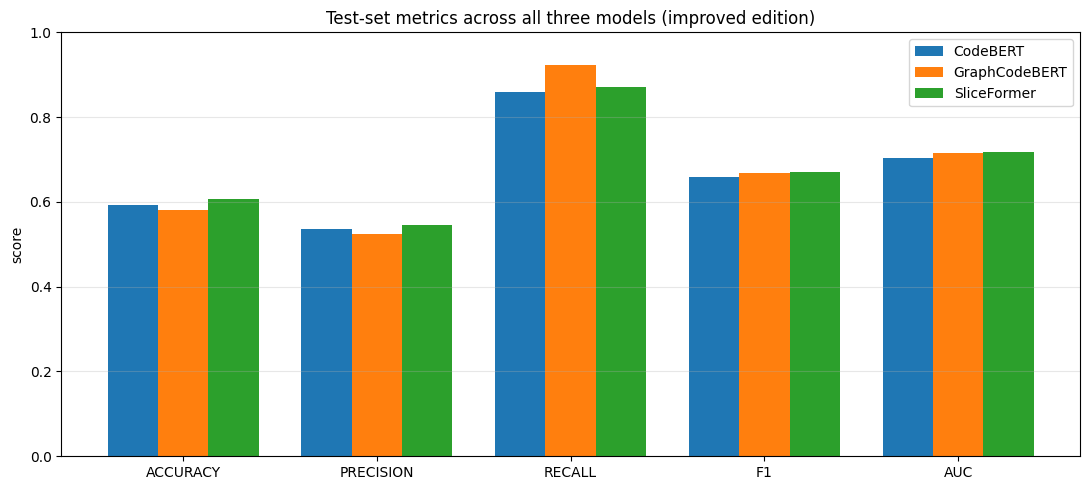

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
bar_metrics = ["accuracy", "precision", "recall", "f1", "auc"]
x_pos = np.arange(len(bar_metrics))
width = 0.26
for i, (name, res) in enumerate(ALL_RESULTS.items()):
    vals = [res[m] for m in bar_metrics]
    ax.bar(x_pos + i * width, vals, width, label=name, color=colors[name])
ax.set_xticks(x_pos + width)
ax.set_xticklabels([m.upper() for m in bar_metrics])
ax.set_ylabel("score")
ax.set_ylim(0, 1.0)
ax.set_title("Test-set metrics across all three models (improved edition)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("sliceformer_metrics_bar.png", dpi=120, bbox_inches="tight")
plt.show()


## 13. Save results

In [ ]:
OUTPUT_DIR = "./results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

serializable_results = {}
for name, res in ALL_RESULTS.items():
    serializable_results[name] = {
        k: float(v) for k, v in res.items()
        if k in {"accuracy", "precision", "recall", "f1", "auc", "threshold"}
    }

summary = {
    "config":            CONFIG,
    "improvements":      [
        "guard-aware slicing (enclosing if/while/for conditions captured)",
        "class-weighted cross-entropy loss",
        "freeze_slice_layers=8 (top 4 layers of slice encoder trainable)",
        "validation threshold tuning by F1",
    ],
    "num_epochs":        NUM_EPOCHS,
    "splits":            {"train": len(train_data),
                          "val":   len(val_data),
                          "test":  len(test_data)},
    "metrics":           serializable_results,
    "histories": {
        "CodeBERT":      codebert_history,
        "GraphCodeBERT": graphcb_history,
        "SliceFormer":   sliceformer_history,
    },
}
with open(f"{OUTPUT_DIR}/results_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)
print(f"Wrote {OUTPUT_DIR}/results_summary.json")

torch.save({
    "state_dict":   sliceformer_model.state_dict(),
    "config":       CONFIG,
    "test_metrics": serializable_results["SliceFormer"],
}, f"{OUTPUT_DIR}/sliceformer_best.pt")
print(f"Wrote {OUTPUT_DIR}/sliceformer_best.pt")

for name, res in ALL_RESULTS.items():
    path = f"{OUTPUT_DIR}/{name.lower()}_test_preds.txt"
    with open(path, "w") as f:
        for p in res["preds"]:
            f.write(f"{int(p)}\n")
    print(f"Wrote {path}")


Wrote ./results/results_summary.json
Wrote ./results/sliceformer_best.pt
Wrote ./results/codebert_test_preds.txt
Wrote ./results/graphcodebert_test_preds.txt
Wrote ./results/sliceformer_test_preds.txt


## 14. Takeaways

- All three models share the same training recipe (class-weighted loss, best-checkpoint-by-F1, threshold tuning).
- The `Threshold` row in the comparison table shows the F1-optimal probability threshold each model picked on the validation set. SliceFormer often picks a *different* threshold than the baselines because its probability calibration differs — that's expected.
- **The relevant comparison is SliceFormer vs. GraphCodeBERT** (same Channel A encoder), not SliceFormer vs. CodeBERT. Any gain over GraphCodeBERT is attributable specifically to the slice channel + cross-attention.
- For security applications, the recall and F1 numbers matter more than accuracy. With class-weighted loss + threshold tuning, all three models are now optimized in that direction.